In [2]:
import numpy as np
from millet import architecture, turtle, water, vptlkdisplay
from hydroroot import length, conductance, display, radius,flux
from openalea.plantgl.all import Viewer
reload(turtle)
reload(water)
reload(radius)
reload(conductance)
reload(flux)
reload(architecture)

C:\Python27\lib\site-packages\matplotlib\cbook.py:122: MatplotlibDeprecationWarning: The matplotlib.mpl module was deprecated in version 1.3. Use `import matplotlib as mpl` instead.
  warnings.warn(message, mplDeprecation, stacklevel=1)
ERROR - 19:02:57 - Cannot load container_wralea.mesh : No module named container_wralea.mesh - c:\python27\lib\site-packages\openalea.core-1.2.0-py2.7.egg\openalea\core\pkgmanager.py - 252
ERROR - 19:02:57 - Cannot load sequence_analysis_wralea.demo.change_point : No module named demo.change_point - c:\python27\lib\site-packages\openalea.core-1.2.0-py2.7.egg\openalea\core\pkgmanager.py - 252


<module 'millet.architecture' from 'c:\users\ndour\desktop\mon dossier\my_ph.d\modeling_and_programming\codes-mtg\svn\millet\src\millet\architecture.pyc'>

In [3]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


`%matplotlib` prevents importing * from pylab and numpy


Define a length law of LRs using equal amplitudes method from measured data
========================================

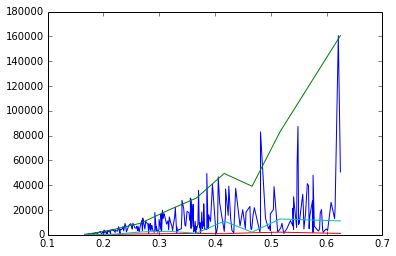

In [4]:
from millet import law
from hydroroot.read_file import readCSVFile

filename = 'lr_length_law_data.csv'
xy = readCSVFile(filename)

LR_length_law = law.expovariate_law(xy, plot=True)


In [5]:
#g = architecture.millet_mtg(LR_length_law = LR_length_law,nb_vertices=1500)
g = architecture.millet_mtg()
g = law.developmental_age(g,15)

In [6]:
position = g.property('position')
#print position.values()


 Compute diameters and radius for different root types
 ----------------------------------------------
 
 * Define evolution laws of diameters of different root types

In [7]:
import math

seminal_RootDiameter_law = lambda x: 70.42*math.log(x) + 282.45
crown_RootDiameter_law = lambda x: 59.15*math.log(x) + 416.57
lr_RootDiameter_law = lambda x: 29.95*math.log(x) + 286.32

In [8]:
g = law.compute_diameter(g, 
                        seminal_RootDiameter_law = seminal_RootDiameter_law,
                        crown_RootDiameter_law = crown_RootDiameter_law,
                        lr_RootDiameter_law = lr_RootDiameter_law)

In [9]:
g= law.radius_from_computed_diameters(g) # for radius computation

In [10]:
#for t in range(1, age_max, 1):
#    g, scene = turtle.mtg_turtle_time(g,t)
#    turtle.Plot(scene)

In [11]:
age = g.property('age')
t= max(age.values())
g, scene = turtle.mtg_turtle_time(g,t)
#turtle.Plot(scene)


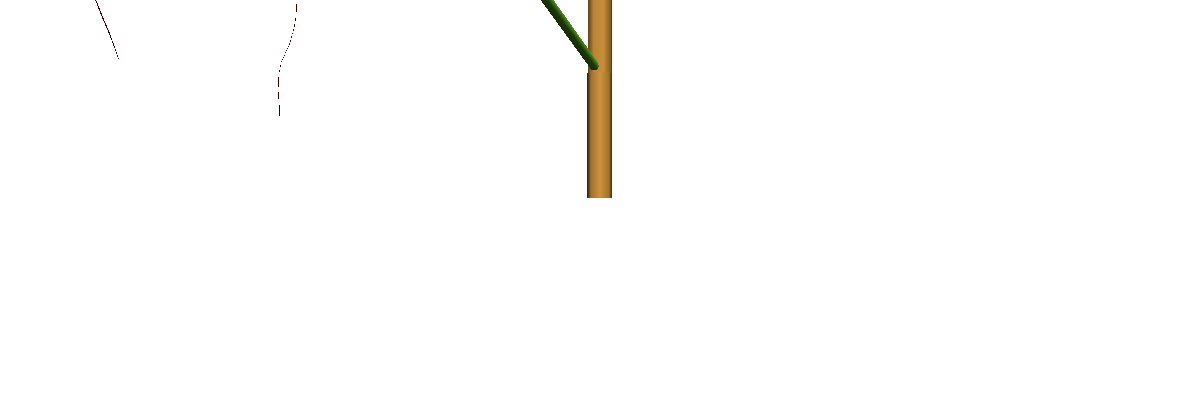

In [12]:
from IPython.display import display
m = vptlkdisplay.PlantGL(scene)
display(m)



Use HydroRoot model to compute Water flux
==========================================

In [14]:
length_data = [0., 0.03, 0.05, 0.16], [0., 0., 0.01, 0.13]
#x = [0., 0.16, 0.05, 0.03]
#y = [0., 0., 0.01, 0.13]
#plot(x,y)
radial_conductivity_data = (
    [0., 0.015, 0.03, 0.045, 0.06, 0.075, 0.09, 0.105, 0.135, 0.15, 0.16], 
    [300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300])
# we define an evolution law of conductance  in hydroroot.conductance
#axial_conductivity_data = ([0., 0.015, 0.03, 0.045, 0.06, 0.075, 0.09, 0.105, 0.135, 0.15, 0.16], [1e-4, 1e-4, 1e-4, 4e-4, 4e-4, 2e-3, 2e-3, 2.5e-3, 2.5e-3, 1e-2, 1e-1])

In [15]:
segment_length = 1e-4
ref_radius = 1e-4 # in m
order_decrease_factor = 0.7

# parameters
k0 = 300
Jv = 0.1
psi_e = 0.4
psi_base = 0.1


    


In [16]:
#Computation of Flux in millet

#Computation of g, surface, volume, Keq, Jv_global 

g, surface, volume, Keq, Jv_global = water.hydrolic(
    g,
    segment_length=segment_length,
    ref_radius = ref_radius,
    order_decrease_factor = order_decrease_factor,
    k0 = k0,
    Jv = Jv,
    psi_e = psi_e,
    psi_base = psi_base,
    length_data=length_data,
    axial_conductivity_data=None,
    radial_conductivity_data=radial_conductivity_data
    )

J_out = g.property('J_out')
efflux = [ J_out[v] for v in g.vertices() if g.label(v)=='Seminal']
#print efflux

print "surface: {}, volume:{} , Keq: {}, Jv_global:{}".format(surface,volume,Keq,Jv_global) 

surface: 0.0274197629431, volume:0.000289091877345 , Keq: 8.22590084752, Jv_global:2.46777025426


Visualization of water fluxes in millet root system
==========================================

In [17]:
from openalea.mtg.mtg import *
from openalea.mtg.io import *
from openalea.mtg.traversal import *
from openalea.mtg.turtle import *
from openalea.mtg.plantframe.color import *


from millet import architecture
import random
import numpy as np

from collections import defaultdict



############################################################
# TODO : Move this code to mtg (CPL)


LR_root_angle= defaultdict(lambda: random.normalvariate(53.52674,15.14071)) #we store the lateral root angles in a default dictionary
#average_CR_angle= 20.03194444
average_CR_angle= 30.03194444
segment_length = 1e-4
    
def visitor(g, v, turtle, time, LR_root_angle=LR_root_angle, average_CR_angle=average_CR_angle, segment_length=segment_length):
    g.properties()['geometry'] = {}
    orders = g.property('order')
    diameters = g.property('diam')
    max_scale = g.max_scale()

    start_dates = g.property(time_property)

    turtle.setId(v)
    #LR_root_angle=30
    if g.edge_type(v) == '+':         #For crown root angles, the size is weak, so we use a mean to estimate their branching
        if g.label(v)=='Crown':
            turtle.down(90-average_CR_angle)
            turtle.setWidth(segment_length*diameters[v])


        else: #We use here a normal law to simulate the LR angle values seeing that they follow a Gaussian distribution
            turtle.down(LR_root_angle[v])
            turtle.setWidth(segment_length*diameters[v])

    # use rather curves to define crown roots tortuosity
    elif g.label(v)=='Crown':
        random.seed(v)
        turtle.setWidth(segment_length*diameters[v])
        turtle.down(random.randint(-2,5))


    elif g.label(v) == 'Seminal':
        #Define SR tortuosity
        if orders.get(v) == 0: 
            random.seed(v)
            turtle.setWidth(segment_length*diameters[v])
            turtle.down(random.randint(-3,3)) 

        #Define LR tortuosity
        else:
            random.seed(v)
            turtle.setWidth(segment_length*diameters[v])
            turtle.down(random.randint(-5,5))

    if g.label(v) == 'collet':
        turtle.rollL(90.)

    turtle.setColor(orders[v]+1)
    turtle.F()
    turtle.rollL()
    pt = turtle.getPosition()
    g.node(v).xyz = pt

    

In [18]:
import numpy as np
from matplotlib import pyplot, mpl
from pylab import cm, colorbar
from pylab import plot as pylab_plot
from matplotlib.colors import Normalize, LogNorm

from openalea.mtg.plantframe import color

import openalea.plantgl.all as pgl

from hydroroot import radius



def plot(g, has_radius=False, r_base=1.e-4, r_tip=5e-5, visitor=visitor, prop_cmap='radius', cmap='jet',lognorm=True):
    
    #r_base, r_tip = float(r_base), float(r_tip)
    
    #if not has_radius:
        #radius.discont_radius(g,r_base=r_base, r_tip=r_tip)

    #turtle = turt.PglTurtle()
    #turtle.down(180)
    #scene = turt.TurtleFrame(g, visitor= visitor, turtle=turtle, gc=False)
    
    g, scene = turtle.mtg_turtle_time(g,t)

    # Compute color from radius
    color.colormap(g,prop_cmap, cmap=cmap, lognorm=lognorm)

    shapes = dict( (sh.getId(),sh) for sh in scene)

    colors = g.property('color')
    for vid in colors:
        shapes[vid].appearance = pgl.Material(colors[vid])
    scene = pgl.Scene(shapes.values())
    return scene






In [20]:
scene = plot(g, has_radius=True, visitor=visitor, prop_cmap='j', lognorm=False)
Viewer.display(scene)



Add a Soil and compute $\Psi_e$
===============================

In [114]:
soil_potential = (
[0., 0.10, 0.5, 1.],
[0.1, 0.1, 0.4, 0.8]
)
x, y = soil_potential

# Compute absolute z coordinate and normalize
vids = g.property('xyz').keys()
zs = np.array([pt.z * segment_length for pt in g.property('xyz').itervalues()])
zs/=zs.max()
zs = zs.tolist()
# Fit data on z coordinate to compute psi_e on each vertex 
g.properties()['height'] = dict(zip(vids,zs)) 
soil_law = length.fit_law(x,y)
g = conductance.fit_property_from_spline(g, soil_law, 'height', 'psi_e')

In [115]:
g, surface, volume, Keq, Jv_global = water.hydrolic(
    g,
    segment_length=segment_length,
    ref_radius = ref_radius,
    order_decrease_factor = order_decrease_factor,
    k0 = k0,
    Jv = Jv,
    psi_e = None,
    psi_base = psi_base,
    length_data=length_data,
    axial_conductivity_data=None,
    radial_conductivity_data=radial_conductivity_data,
    )


In [116]:
scene = plot(g, has_radius=True, visitor=visitor, prop_cmap='psi_out', lognorm=False)
Viewer.display(scene)